# Crosschecking the taux_pauvrete and amounf of demandeur_emploi with the duration and frecuency of climate events


## Extracting and cleaning data with DuckDB and Pandas


In [2]:
import pandas as pd

pd.set_option("display.max_columns", None)  # show all cols
pd.set_option("display.max_colwidth", None)  # show full width of showing cols
pd.set_option(
    "display.expand_frame_repr", False
)  # print cols side by side as it's supposed to be

In [3]:
# Nous commencons par importer les librairies nécessaires pour l'analyse des données.

import duckdb

ODIS_DUCKDB_FILE = "odis.duckdb"
PCC_DUCKDB_FILE = "dev.duckdb"

con = duckdb.connect(database=PCC_DUCKDB_FILE, read_only=True)
con.sql(f"ATTACH '{ODIS_DUCKDB_FILE}' AS odis;")

In [4]:
# informacion de comunas y riesgos
query_catnat = """
SELECT *
  FROM dev.main.catnat_gaspar
  ORDER BY cod_commune ASC;
"""

cat_nat_2000 = con.sql(query_catnat)
cat_nat_2000_df = cat_nat_2000.df()

query_odis1 = """SELECT * FROM odis.gold_gold_com_dep_reg
ORDER BY CODGEO ASC;"""
odis_geolocalisation = con.sql(query_odis1).df()
odis_geolocalisation.head(2)

query_odis2 = """SELECT * FROM odis.gold_gold_emploi_demandeur
ORDER BY codgeo ASC;
"""
odis_emploi_demandeur = con.sql(query_odis2).df()
odis_emploi_demandeur["codgeo"] = odis_emploi_demandeur["codgeo"].str.zfill(5)


query_odis3 = """SELECT * FROM odis.gold_gold_typologies_territoires
ORDER BY codgeo ASC;"""
odis_topology = con.sql(query_odis3).df()


query_odis4 = """SELECT * FROM odis.gold_gold_population_taux_pauvrete
ORDER BY codgeo ASC;"""
odis_population_taux_pauvrete = con.sql(query_odis4).df()


In [5]:
cat_nat_2000_df.head(12)

,cod_nat_catnat,cod_commune,lib_commune,num_risque_jo,lib_risque_jo,dat_deb,dat_fin,dat_pub_arrete,dat_pub_jo,dat_maj
0,NOR19840921,01001,L'Abergement-Clémenciat,ICB,Inondations et/ou Coulées de Boue,1984-06-21 00:00:00,1984-06-21 00:00:00,1984-09-21 00:00:00,1984-10-18 00:00:00,2022-05-20 15:53:08.537
1,IOCE0911363A,01001,L'Abergement-Clémenciat,ICB,Inondations et/ou Coulées de Boue,2009-02-06,2009-02-07,2009-05-18,2009-05-21,2022-05-24 11:39:23.768
2,INTE9000113A,01002,L'Abergement-de-Varey,ICB,Inondations et/ou Coulées de Boue,1990-02-13,1990-02-18,1990-03-16,1990-03-23,2022-05-20 15:55:32.884
3,INTE0000591A,01002,L'Abergement-de-Varey,ICB,Inondations et/ou Coulées de Boue,2000-06-14,2000-06-14,2000-10-25,2000-11-15,2022-05-24 11:24:14.603
4,INTX9210072A,01004,Ambérieu-en-Bugey,ICB,Inondations et/ou Coulées de Boue,1991-12-21,1991-12-24,1992-03-11,1992-03-29,2022-05-20 15:57:23.349
5,IOME2415881A,01004,Ambérieu-en-Bugey,SEC,Sécheresse,2023-01-01 01:00:00,2023-03-31 02:00:00,2024-06-18 02:00:00,2024-07-02 02:00:00,2024-07-04 02:00:00.000
6,NOR19830906,01004,Ambérieu-en-Bugey,ICB,Inondations et/ou Coulées de Boue,1983-05-01,1983-05-31,1983-09-06,1983-09-11,2022-05-20 15:50:52.380
7,NOR19830906,01004,Ambérieu-en-Bugey,MVT,Mouvement de Terrain,1983-05-01,1983-05-31,1983-09-06,1983-09-11,2022-05-20 15:50:52.380
8,IOME2308745A,01004,Ambérieu-en-Bugey,SEC,Sécheresse,2022-01-01 01:00:00,2022-09-30 02:00:00,2023-04-03 02:00:00,2023-05-03 02:00:00,2023-05-04 02:00:00.000
9,INTE1917051A,01004,Ambérieu-en-Bugey,SEC,Sécheresse,2018-07-01,2018-12-31,2019-06-18,2019-07-17,2022-05-24 11:53:51.185


In [6]:
query_cat = """
SELECT *
  FROM dev.main.catnat_gaspar WHERE lib_risque_jo='Sécheresse'
  ORDER BY cod_commune ASC;
"""

bycatastrofe = con.sql(query_cat)
bycatastrofe_df = bycatastrofe.df()
bycatastrofe_df.head(12)

,cod_nat_catnat,cod_commune,lib_commune,num_risque_jo,lib_risque_jo,dat_deb,dat_fin,dat_pub_arrete,dat_pub_jo,dat_maj
0,IOME2308745A,01004,Ambérieu-en-Bugey,SEC,Sécheresse,2022-01-01 01:00:00,2022-09-30 02:00:00,2023-04-03 02:00:00,2023-05-03 02:00:00,2023-05-04 02:00:00.000
1,IOME2415881A,01004,Ambérieu-en-Bugey,SEC,Sécheresse,2023-01-01 01:00:00,2023-03-31 02:00:00,2024-06-18 02:00:00,2024-07-02 02:00:00,2024-07-04 02:00:00.000
2,INTE0400656A,01004,Ambérieu-en-Bugey,SEC,Sécheresse,2003-07-01,2003-09-30,2004-08-25,2004-08-26,2022-05-24 11:27:34.306
3,INTE1917051A,01004,Ambérieu-en-Bugey,SEC,Sécheresse,2018-07-01,2018-12-31,2019-06-18,2019-07-17,2022-05-24 11:53:51.185
4,INTE2127289A,01004,Ambérieu-en-Bugey,SEC,Sécheresse,2020-04-01,2020-09-30,2021-09-14,2021-09-28,2022-05-24 11:58:21.501
5,IOME2308745A,01007,Ambronay,SEC,Sécheresse,2022-04-01 02:00:00,2022-09-30 02:00:00,2023-04-03 02:00:00,2023-05-03 02:00:00,2023-05-04 02:00:00.000
6,IOME2415881A,01007,Ambronay,SEC,Sécheresse,2023-01-01 01:00:00,2023-03-31 02:00:00,2024-06-18 02:00:00,2024-07-02 02:00:00,2024-07-04 02:00:00.000
7,INTE2118485A,01007,Ambronay,SEC,Sécheresse,2020-04-01,2020-09-30,2021-06-22,2021-07-09,2022-05-24 11:57:30.068
8,INTE1917051A,01007,Ambronay,SEC,Sécheresse,2018-07-01,2018-12-31,2019-06-18,2019-07-17,2022-05-24 11:53:51.185
9,INTE0400918A,01007,Ambronay,SEC,Sécheresse,2003-07-01,2003-09-30,2005-01-11,2005-02-01,2022-05-24 11:28:00.127


In [7]:
# Cleaning Climate data
from datetime import datetime

cat_nat_2000_df.head(10)
climate_data = pd.DataFrame(
    {
        "lib_commune": cat_nat_2000_df["lib_commune"],
        "cod_commune": cat_nat_2000_df["cod_commune"],
        "climate_risk": cat_nat_2000_df["lib_risque_jo"],
        "durée événement": pd.to_datetime(cat_nat_2000_df["dat_fin"], format="mixed")
        - pd.to_datetime(cat_nat_2000_df["dat_deb"], format="mixed"),
    }
)
df_climate = (
    climate_data.groupby(["cod_commune", "lib_commune", "climate_risk"])
    .agg(duree_total=("durée événement", "sum"), nb_events=("durée événement", "count"))
    .reset_index()
)
df_climate

,cod_commune,lib_commune,climate_risk,duree_total,nb_events
0,01001,L'Abergement-Clémenciat,Inondations et/ou Coulées de Boue,1 days 00:00:00,2
1,01002,L'Abergement-de-Varey,Inondations et/ou Coulées de Boue,5 days 00:00:00,2
2,01004,Ambérieu-en-Bugey,Inondations et/ou Coulées de Boue,39 days 00:00:00,4
3,01004,Ambérieu-en-Bugey,Mouvement de Terrain,30 days 00:00:00,1
4,01004,Ambérieu-en-Bugey,Sécheresse,817 days 02:00:00,5
...,...,...,...,...,...
104466,97616,Sada,Vents Cycloniques,2 days 00:00:00,1
104467,97617,Tsingoni,Chocs Mécaniques liés à l'action des Vagues,2 days 00:00:00,1
104468,97617,Tsingoni,Inondations et/ou Coulées de Boue,2 days 00:00:00,1
104469,97617,Tsingoni,Secousse Sismique,416 days 00:00:00,1


In [8]:
# Cleaning Socio-economic data
df_demandeur = (
    odis_emploi_demandeur.groupby("codgeo")
    .agg(nb_demandeurs=("Demandeurs_Emploi", "mean"))
    .reset_index()
)


odis_population_taux_pauvrete.fillna(0, inplace=True)
odis_population_taux_pauvrete["codgeo"] = (
    odis_population_taux_pauvrete["codgeo"].astype(str).str.zfill(5)
)

df_pauvrete = (
    odis_population_taux_pauvrete.groupby("codgeo")
    .agg(TP40=("TP40", "mean"), TP50=("TP50", "mean"), TP60=("TP60", "mean"))
    .reset_index()
)
merged = pd.merge(df_demandeur, df_pauvrete, left_on="codgeo", right_on="codgeo")
df_socio = pd.merge(
    merged, odis_topology, left_on="codgeo", right_on="codgeo"
).reset_index(drop=True)

df_socio["nb_demandeurs"] = df_socio["nb_demandeurs"] / df_socio["population"]
df_socio.head(5)

,codgeo,nb_demandeurs,TP40,TP50,TP60,libellé,tranche_de_population,population
0,01004,0.111823,5.0,9.0,17.0,Ambérieu-en-Bugey,Entre 10000 et 50000,15554
1,01033,0.118213,6.0,11.0,17.0,Valserhône,Entre 10000 et 50000,16162
2,01034,0.095264,5.0,10.0,18.0,Belley,Entre 5000 et 10000,9270
3,01053,0.117578,7.0,13.0,24.0,Bourg-en-Bresse,Entre 10000 et 50000,42065
4,01071,0.066225,0.0,5.0,7.0,Cessy,Entre 5000 et 10000,5570


### Group by population and type of cliamte event


In [9]:
mas_pobres = df_socio.sort_values("TP60")["codgeo"].tail(10)
mas_pobres = mas_pobres.tolist()
mas_pobres

['59172',
 '30132',
 '97407',
 '91286',
 '97409',
 '97410',
 '59512',
 '97419',
 '97424',
 '97421']

In [10]:
causes = []
for _, row in df_climate.iterrows():
    if row["cod_commune"] in mas_pobres:
        causes.append(row["climate_risk"])
causes

['Inondations et/ou Coulées de Boue',
 'Tempête',
 'Inondations et/ou Coulées de Boue',
 'Mouvement de Terrain',
 'Secousse Sismique',
 'Sécheresse',
 'Inondations et/ou Coulées de Boue',
 'Mouvement de Terrain',
 'Sécheresse',
 'Inondations et/ou Coulées de Boue',
 'Mouvement de Terrain',
 'Sécheresse',
 "Chocs Mécaniques liés à l'action des Vagues",
 'Inondations et/ou Coulées de Boue',
 'Mouvement de Terrain',
 'Vents Cycloniques',
 "Chocs Mécaniques liés à l'action des Vagues",
 'Inondations et/ou Coulées de Boue',
 'Mouvement de Terrain',
 'Vents Cycloniques',
 "Chocs Mécaniques liés à l'action des Vagues",
 'Inondations et/ou Coulées de Boue',
 'Mouvement de Terrain',
 'Vents Cycloniques',
 "Chocs Mécaniques liés à l'action des Vagues",
 'Inondations et/ou Coulées de Boue',
 'Mouvement de Terrain',
 "Chocs Mécaniques liés à l'action des Vagues",
 'Inondations et/ou Coulées de Boue',
 'Mouvement de Terrain',
 'Vents Cycloniques',
 "Chocs Mécaniques liés à l'action des Vagues",
 'I

In [11]:
causes.count("Sécheresse")
causes.count("Inondations et/ou Coulées de Boue")

10

In [12]:
# Merging both datasets
df_merged = pd.merge(df_climate, df_socio, left_on="cod_commune", right_on="codgeo")
df_merged = df_merged.drop(columns=["codgeo", "lib_commune"])
df_merged.head(5)
df_merged["duree_total"] = df_merged["duree_total"].dt.total_seconds() / 60

## Graphs


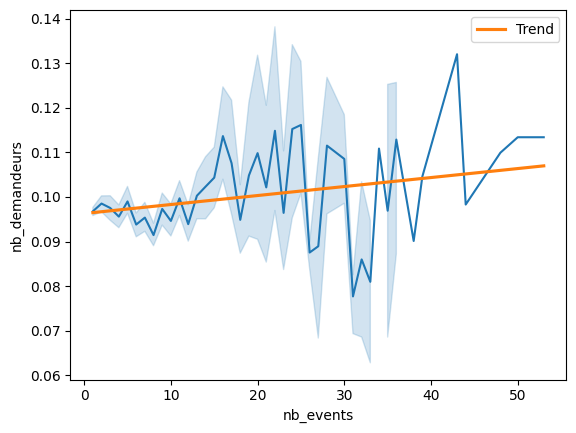

In [13]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.lineplot(data=df_merged, x="nb_events", y="nb_demandeurs")

sns.regplot(
    data=df_merged,
    x="nb_events",
    y="nb_demandeurs",
    scatter=False,  # no puntos
    ci=False,  # sin intervalo de confianza
    label="Trend",
)

plt.legend()
plt.show()

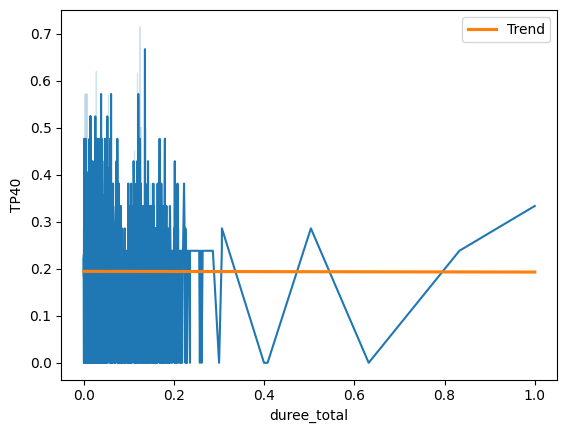

In [14]:
from sklearn.preprocessing import MinMaxScaler
import numpy as np

scaler = MinMaxScaler()
df_scaled = df_merged.copy()
df_scaled[["TP40", "duree_total"]] = scaler.fit_transform(
    df_merged[["TP40", "duree_total"]]
)

sns.lineplot(data=df_scaled, x="duree_total", y="TP40")
sns.regplot(
    data=df_scaled,
    x="duree_total",
    y="TP40",
    scatter=False,
    ci=False,
    label="Trend",
)

plt.legend()
plt.show()

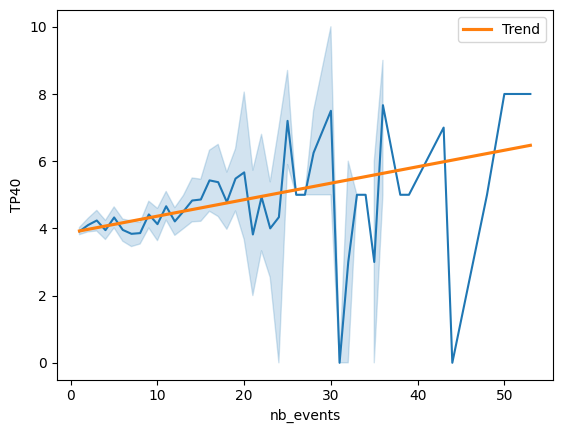

In [15]:
sns.lineplot(data=df_merged, x="nb_events", y="TP40")
sns.regplot(
    data=df_merged,
    x="nb_events",
    y="TP40",
    scatter=False,  # no puntos
    ci=False,  # sin intervalo de confianza
    label="Trend",
)

plt.legend()
plt.show()

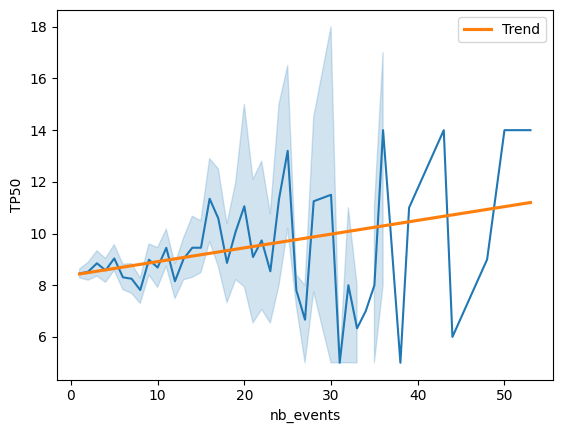

In [16]:
sns.lineplot(data=df_merged, x="nb_events", y="TP50")
sns.regplot(
    data=df_merged, x="nb_events", y="TP50", scatter=False, ci=True, label="Trend"
)

plt.legend()
plt.show()

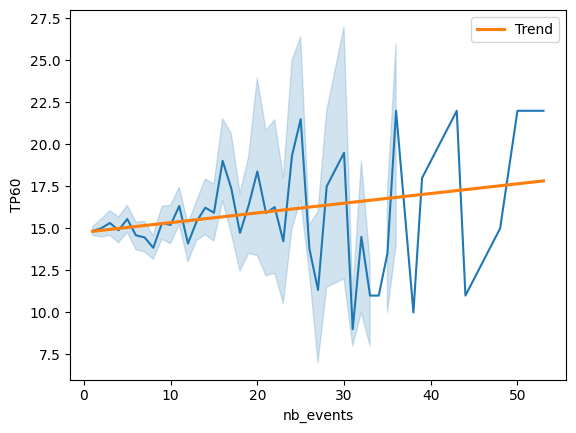

In [17]:
sns.lineplot(data=df_merged, x="nb_events", y="TP60")
sns.regplot(
    data=df_merged,
    x="nb_events",
    y="TP60",
    scatter=False,  # no puntos
    ci=False,  # sin intervalo de confianza
    label="Trend",
)

plt.legend()
plt.show()

## Correlations


In [18]:
# All correaltions done with different methods show a week correlation, lower than 0.1
corr1 = df_merged[["nb_events", "nb_demandeurs"]].corr(method="spearman")
print(corr1)

corr2 = df_merged[["nb_events", "nb_demandeurs"]].corr(method="pearson")
print(corr2)

corr3 = df_merged[["nb_events", "nb_demandeurs"]].corr(method="kendall")
print(corr3)

corr4 = df_merged[["nb_events", "TP60"]].corr(method="spearman")
print(corr4)

corr5 = df_merged[["nb_events", "TP60"]].corr(method="pearson")
print(corr5)

corr6 = df_merged[["nb_events", "TP60"]].corr(method="kendall")
print(corr6)


               nb_events  nb_demandeurs
nb_events       1.000000       0.013651
nb_demandeurs   0.013651       1.000000
               nb_events  nb_demandeurs
nb_events       1.000000       0.034641
nb_demandeurs   0.034641       1.000000
               nb_events  nb_demandeurs
nb_events       1.000000       0.009937
nb_demandeurs   0.009937       1.000000
           nb_events      TP60
nb_events   1.000000  0.029904
TP60        0.029904  1.000000
           nb_events      TP60
nb_events   1.000000  0.035963
TP60        0.035963  1.000000
           nb_events      TP60
nb_events   1.000000  0.022149
TP60        0.022149  1.000000


In [19]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score, mean_squared_error


X = df_merged[["nb_demandeurs", "TP40", "TP50", "TP60"]]
y = df_merged["nb_events"]


model = LinearRegression()
model.fit(X, y)

y_pred = model.predict(X)

r2 = r2_score(y, y_pred)
print("R^2:", r2)
mse = mean_squared_error(y, y_pred)
print("MSE:", mse)

R^2: 0.008754250027992572
MSE: 22.840984249070466
